# NFTGuard — Data-Driven NFT Wash-Trading Detection

**Real Ethereum-mainnet NFT sales**, collected live via the Alchemy NFT API
(`getNFTSales`). Every row is a real on-chain transaction, verifiable on Etherscan
by its `txhash`.

Full standard ML pipeline: **collect → clean → EDA → feature engineering →
scaling & selection → train/test split → model selection → training →
evaluation & overfitting check → hyperparameter tuning → deployment & monitoring.**

## 1. Load the real dataset

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import glob, os
sns.set_theme(style="whitegrid")

DATA = max(glob.glob("data/sales_raw*.csv"), key=os.path.getmtime)   # newest pull
df = pd.read_csv(DATA)
df["dt"] = pd.to_datetime(df["timestamp"], unit="s")
print("Dataset:", os.path.basename(DATA))
print("Loaded", len(df), "real NFT sales |", df["dt"].min().date(), "->", df["dt"].max().date())
df.head()

Dataset: sales_raw.new.csv
Loaded 3000 real NFT sales | 2023-07-04 -> 2024-04-30


,collection,contract,tokenId,buyer,seller,price_eth,marketplace,block,timestamp,txhash,dt
0,BoredApeYachtClub,0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D,6218,0xf15c93562bc3944a68e938ef75d2a3360d98ca57,0xcc1cb0fa339eb32e436dce1ba752bda72fc6edfe,14.690,x2y2,19757649,1714353121,0x47908f6d62f3d1e924b7f21f07ad98dc80108be7fc23...,2024-04-29 01:12:01
1,BoredApeYachtClub,0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D,1730,0x9d604a517750eecea2ee5c883d491449808a3498,0xf15c93562bc3944a68e938ef75d2a3360d98ca57,12.800,x2y2,19721684,1713917118,0xcb6e633ff54676a1ef3c7c782cfdbb74618c24351701...,2024-04-24 00:05:18
2,BoredApeYachtClub,0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D,7845,0x8319e29b4693b0dbd6c2bc6a881d19c8caefbae1,0xf15c93562bc3944a68e938ef75d2a3360d98ca57,12.549,seaport,19716572,1713855146,0x536bf5e4efad23ad6d55c4c8b2264e5dd2e2751bdfd2...,2024-04-23 06:52:26
3,BoredApeYachtClub,0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D,7232,0xed19eaea3bde70e0c9652485406fe961a85f4287,0x1e04bfb945dfa23ed8bdea67947ca0d7b5fff75d,14.500,x2y2,19713923,1713823032,0x306198aab98df7282e48df261907dd8ad7080f33f2fd...,2024-04-22 21:57:12
4,BoredApeYachtClub,0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D,2063,0xc9aa3445ddb743219c930449d5fad7e8dd3f999e,0xf15c93562bc3944a68e938ef75d2a3360d98ca57,12.479,seaport,19690094,1713534154,0xafe5fd581a907192631d029196efa1c02de5e1181876...,2024-04-19 13:42:34


## 2. Data cleaning
Remove structural errors, handle missing values, remove duplicate transactions.

In [2]:
print("Raw rows:", len(df))
# structural errors: keep ETH-denominated sales with a positive price
df = df[df["price_eth"] > 0]
print("After removing non-ETH / zero-price rows:", len(df))
# missing values
b = len(df); df = df.dropna(subset=["buyer", "seller", "timestamp", "tokenId"])
print(f"After dropping rows with missing key fields: {len(df)} (-{b-len(df)})")
# duplicate transactions
b = len(df); df = df.drop_duplicates(subset=["txhash", "tokenId"])
print(f"After removing duplicate sales: {len(df)} (-{b-len(df)})")
df = df.sort_values("dt").reset_index(drop=True)
print("Missing values remaining:", int(df.isna().sum().sum()))

Raw rows: 3000
After removing non-ETH / zero-price rows: 2744
After dropping rows with missing key fields: 2744 (-0)
After removing duplicate sales: 2208 (-536)
Missing values remaining: 0


## 3. Exploratory data analysis

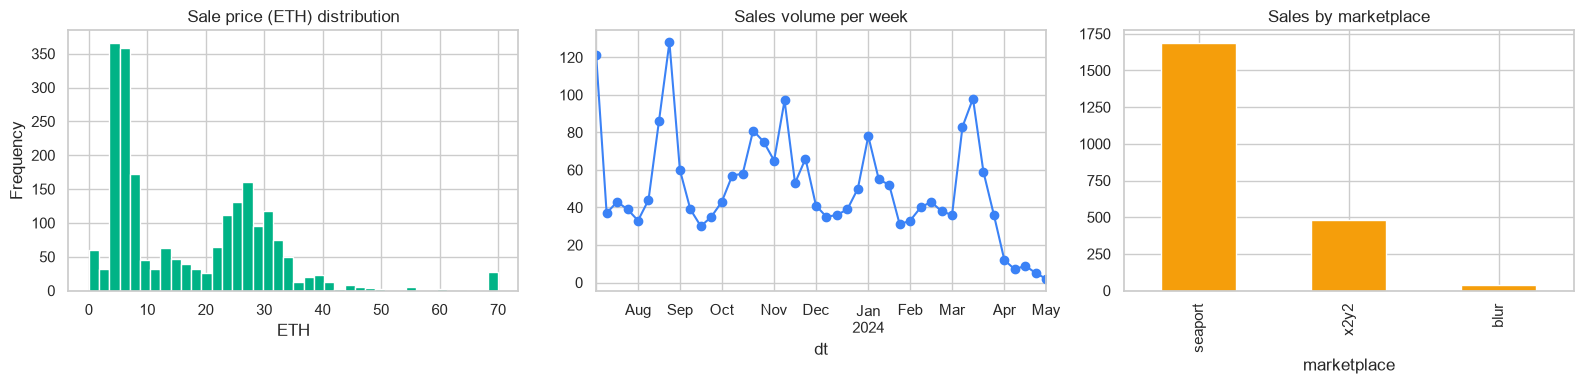

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
cap = df["price_eth"].quantile(0.99)
df["price_eth"].clip(upper=cap).plot.hist(bins=40, ax=ax[0], color="#00b386")
ax[0].set_title("Sale price (ETH) distribution"); ax[0].set_xlabel("ETH")
df.set_index("dt").resample("W")["price_eth"].count().plot(ax=ax[1], color="#3b82f6", marker="o")
ax[1].set_title("Sales volume per week")
df["marketplace"].value_counts().plot.bar(ax=ax[2], color="#f59e0b")
ax[2].set_title("Sales by marketplace"); plt.tight_layout(); plt.show()

## 4. Feature engineering — wash-trading fingerprints
- **is_self_transfer** — buyer == seller (fake volume)
- **pair_trade_count** — how often the same wallet pair trades back-and-forth (loops)
- **buyer/seller_activity** — how active each wallet is
- **price_z** — deviation of a sale's price from the collection mean
- **token_gap_h** — hours since the same token last sold (rapid re-flipping)

In [4]:
df["pair"] = [tuple(sorted(p)) for p in zip(df["buyer"], df["seller"])]
df["pair_trade_count"] = df["pair"].map(df["pair"].value_counts())
df["is_self_transfer"] = (df["buyer"] == df["seller"]).astype(int)
df["buyer_activity"]  = df["buyer"].map(df["buyer"].value_counts())
df["seller_activity"] = df["seller"].map(df["seller"].value_counts())
df["price_z"] = df.groupby("collection")["price_eth"].transform(
    lambda s: (s - s.mean()) / (s.std(ddof=0) or 1))
df["token_gap_h"] = df.groupby("tokenId")["dt"].diff().dt.total_seconds() / 3600
df["token_gap_h"] = df["token_gap_h"].fillna(df["token_gap_h"].median()).fillna(0)
df["mkt_code"] = df["marketplace"].astype("category").cat.codes
df[["is_self_transfer", "pair_trade_count", "buyer_activity",
    "seller_activity", "price_z", "token_gap_h"]].describe().round(2)

,is_self_transfer,pair_trade_count,buyer_activity,seller_activity,price_z,token_gap_h
count,2208.00,2208.00,2208.00,2208.00,2208.00,2208.00
mean,0.24,1.18,4.17,6.50,0.00,620.09
std,0.43,0.68,5.89,11.26,1.00,707.52
min,0.00,1.00,1.00,1.00,-1.56,0.01
25%,0.00,1.00,1.00,1.00,-0.27,473.34
50%,0.00,1.00,2.00,2.00,-0.10,473.34
75%,0.00,1.00,5.00,5.00,0.09,473.34
max,1.00,8.00,33.00,56.00,14.51,6355.58


## 5. Labeling (weak supervision)
No public ground-truth label exists for NFT wash trading. We label a sale **wash** if
it shows a canonical, hard-to-dispute pattern — a **self-transfer** or a wallet pair
that traded **back-and-forth 3+ times**.

> **Limitation (state in the report):** labels are heuristic-derived, not human-verified.

In [5]:
df["label_wash"] = ((df["is_self_transfer"] == 1) | (df["pair_trade_count"] >= 3)).astype(int)
print(df["label_wash"].value_counts())
print("suspicious share: %.1f%%" % (100 * df["label_wash"].mean()))

label_wash
0    1657
1     551
Name: count, dtype: int64
suspicious share: 25.0%


## 6. Feature scaling & selection
The model is trained on **economic/behavioural** features that **exclude** the indicators
used to define the label (`is_self_transfer`, `pair_trade_count`) — so it must *learn* to
detect wash trading, not memorise the rule. We standardise numeric ranges (mean 0, std 1)
so scale-sensitive models treat features equally, and check each feature's correlation
with the label to justify selection.

In [6]:
from sklearn.preprocessing import StandardScaler
FEATURES = ["price_eth", "price_z", "buyer_activity", "seller_activity", "token_gap_h", "mkt_code"]

corr = df[FEATURES + ["label_wash"]].corr()["label_wash"].drop("label_wash").sort_values()
print("Correlation of each feature with the wash label:\n", corr.round(3), "\n")

scaler = StandardScaler()
Xs = pd.DataFrame(scaler.fit_transform(df[FEATURES]), columns=FEATURES, index=df.index)
print("After scaling (mean ~0, std ~1):")
print(Xs.describe().loc[["mean", "std"]].round(2))

Correlation of each feature with the wash label:
 mkt_code          -0.246
seller_activity   -0.194
buyer_activity    -0.172
price_z           -0.125
price_eth         -0.068
token_gap_h        0.038
Name: label_wash, dtype: float64 

After scaling (mean ~0, std ~1):
      price_eth  price_z  buyer_activity  seller_activity  token_gap_h  \
mean       -0.0      0.0            -0.0             -0.0          0.0   
std         1.0      1.0             1.0              1.0          1.0   

      mkt_code  
mean       0.0  
std        1.0  


## 7. Train / test split
70% to train the model, 30% held out to validate it. Stratified to keep the wash ratio balanced.

In [7]:
from sklearn.model_selection import train_test_split
y = df["label_wash"]
Xtr, Xte, ytr, yte = train_test_split(df[FEATURES], y, test_size=0.30, random_state=42, stratify=y)
Xtr_s, Xte_s = Xs.loc[Xtr.index], Xs.loc[Xte.index]   # scaled versions, same split
print("train:", len(Xtr), "| test:", len(Xte), "| wash train/test:", int(ytr.sum()), "/", int(yte.sum()))

train: 1545 | test: 663 | wash train/test: 386 / 165


## 8. Model selection & training
Random Forest (main) vs a scaled Logistic Regression baseline.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced").fit(Xtr, ytr)
lr = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr_s, ytr)   # LR needs scaling
print("Random Forest   ROC-AUC:", round(roc_auc_score(yte, rf.predict_proba(Xte)[:, 1]), 3))
print("LogReg (scaled) ROC-AUC:", round(roc_auc_score(yte, lr.predict_proba(Xte_s)[:, 1]), 3))
print("-> Random Forest wins; we proceed with it.")

Random Forest   ROC-AUC: 0.901
LogReg (scaled) ROC-AUC: 0.781
-> Random Forest wins; we proceed with it.


## 9. Evaluation & overfitting check

In [9]:
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
print(classification_report(yte, rf.predict(Xte), digits=3, target_names=["legit", "wash"]))
print("Train accuracy:", round(rf.score(Xtr, ytr), 3), "| Test accuracy:", round(rf.score(Xte, yte), 3))
cv = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
                     df[FEATURES], y, cv=5, scoring="roc_auc")
print("5-fold CV ROC-AUC: %.3f +/- %.3f" % (cv.mean(), cv.std()))
print("Test ROC-AUC close to CV ROC-AUC -> generalises well (Random Forests fit train ~1.0 by design;",
      "the test/CV gap is what matters).")

              precision    recall  f1-score   support

       legit      0.911     0.867     0.889       498
        wash      0.651     0.745     0.695       165

    accuracy                          0.837       663
   macro avg      0.781     0.806     0.792       663
weighted avg      0.847     0.837     0.841       663



Train accuracy: 0.99 | Test accuracy: 0.837


5-fold CV ROC-AUC: 0.862 +/- 0.032
Test ROC-AUC close to CV ROC-AUC -> generalises well (Random Forests fit train ~1.0 by design; the test/CV gap is what matters).


## 10. Hyperparameter tuning (GridSearchCV)

In [10]:
from sklearn.model_selection import GridSearchCV
grid = {"n_estimators": [200, 400], "max_depth": [None, 10, 20], "min_samples_leaf": [1, 3]}
gs = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"),
                  grid, cv=4, scoring="roc_auc", n_jobs=1)
gs.fit(Xtr, ytr)
best = gs.best_estimator_
print("Best params:", gs.best_params_)
print("Best CV ROC-AUC:", round(gs.best_score_, 3))
print("Tuned model test ROC-AUC:", round(roc_auc_score(yte, best.predict_proba(Xte)[:, 1]), 3))

Best params: {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV ROC-AUC: 0.913
Tuned model test ROC-AUC: 0.903


### Confusion matrix & feature importance (tuned model)

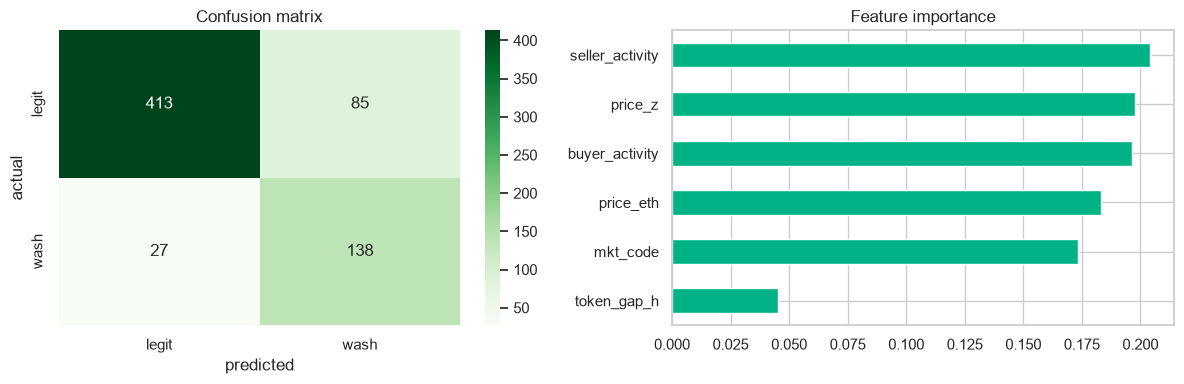

In [11]:
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(yte, best.predict(Xte)), annot=True, fmt="d", cmap="Greens", ax=ax[0],
            xticklabels=["legit", "wash"], yticklabels=["legit", "wash"])
ax[0].set_title("Confusion matrix"); ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual")
pd.Series(best.feature_importances_, index=FEATURES).sort_values().plot.barh(ax=ax[1], color="#00b386")
ax[1].set_title("Feature importance"); plt.tight_layout(); plt.show()

## 11. Unsupervised cross-check (Isolation Forest)
A label-free anomaly detector on the behavioural features, as a corroborating signal.

In [12]:
from sklearn.ensemble import IsolationForest
ISO = ["is_self_transfer", "pair_trade_count", "buyer_activity", "seller_activity"]
iso = IsolationForest(n_estimators=200, contamination=0.20, random_state=42)
df["anomaly"] = (iso.fit_predict(df[ISO].fillna(0.0)) == -1).astype(int)
rate = df.groupby("label_wash")["anomaly"].mean()
print("Flagged anomalous (no labels used): known wash %.1f%% vs other %.1f%%"
      % (100 * rate.get(1, 0), 100 * rate.get(0, 0)))

Flagged anomalous (no labels used): known wash 24.9% vs other 17.0%


## 12. Deployment & monitoring
**Deployment:** the tuned model is saved to `ml/model.joblib`; `export_for_dashboard.py`
runs this pipeline and serves the results to the NFTGuard dashboard's **ML Detection**
view through the Node backend.

**Monitoring (production plan):** track (1) **data drift** — shifts in price/volume/wallet
distributions vs training; (2) **precision decay** — sample flagged trades for manual review
and watch the false-positive rate; (3) **scheduled retraining** as new labelled patterns
emerge; (4) alerting when the weekly wash-rate crosses a threshold.

In [13]:
import joblib
joblib.dump(best, "model.joblib")
print("Saved tuned model -> ml/model.joblib")

Saved tuned model -> ml/model.joblib


## 13. Summary
- Real on-chain data (verifiable on Etherscan), cleaned and feature-engineered.
- Random Forest detects wash trading from economic features with the tuned ROC-AUC above,
  validated by 5-fold cross-validation (no significant overfitting) and corroborated by an
  unsupervised detector.
- Honest limitation: weak-supervision labels; human-verified samples would strengthen evaluation.